# 합성곱 신경망(CNN)

**합성곱 신경망(convolutional neural network)**   
CNN은 이미지 인식과 음성 인식 등 다양한 곳에서 사용되는데, 특히 이미지 인식 분야에서 딥러닝을 활용한 기법은 거의 다 CNN을 기초로 함   
이번 장에서는 CNN의 메터니즘을 자세히 설명하고, 이를 파이썬으로 구현해봄

## 전체 구조

우선 CNN의 네트워크 구조를 살펴보며 전체 틀을 이해해보기   
CNN도 지금까지 본 신경망과 같이 레고 블록처럼 계층을 조합하여 만들 수 있음   
다만, **합성곱 계층(convolutional layer)** 과 **풀링 계층(pooling layer)** 이 새롭게 등장함   

합성곱 계층과 풀링 계층의 상세 내용은 나중에 알아보고,   
이번 절에서는 이 계층들을 어떻게 조합하여 CNN을 만드는지를 먼저 살펴봄   

지금까지 본 신경망은 인접하는 계층의 모든 뉴런과 결합되어 있었음 - **완전연결(fully-connected, 전결합)** 이라고 함   
완전히 연결된 계층을 **Affine 계층** 이라는 이름으로 구현함   

이 Affine 계층을 사용하면, 가령 층이 5개인 완전연결 신경망은 다음 그림과 같이 구현할 수 있음   
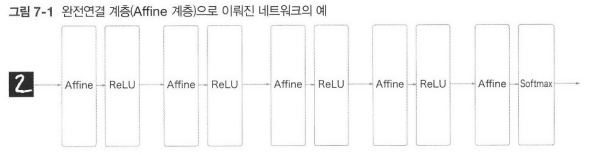   
- 그림과 같이 완전연결 신경망은 Affine 계층 뒤에 활성화 함수를 갖는 ReLU 계층(혹은 Sigmoid 계층)이 이어짐   
- 이 그림에서는 Affine-ReLU 조합이 4개가 쌓였고,
- 마지막 5번째 층은 Affine 계층에 이어 소프트맥스 계층에서 최종 결과(확률)를 출력함   

그럼 CNN의 구조는?   
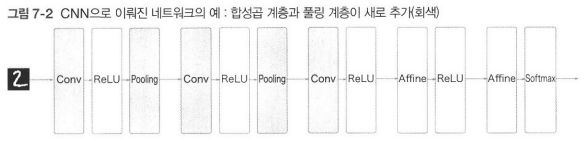   
- 그림과 같이 CNN에서는 새로운 '합성곱 계층(Conv)'과 '풀링 계층(Pooling)'이 추가됨
- CNN 계층은 'Conv-ReLU-(Pooling)' 흐름으로 연결됨 (풀링 계층은 생략하기도 함)
- 지금까지의 'Affine-ReLU' 연결이 'Conv-ReLU-(Pooling)'으로 바뀌었다고 생각할 수 있음
- 그림의 CNN에서 주목할 또 다른 점은 출력에 가까운 층에서는 지금까지의 'Affine-ReLU' 구성을 사용할 수 있다는 것
- 또, 마지막 출력 계층에서는 'Affine-Softmax' 조합을 그대로 사용함  

여기까지가 일반적인 CNN에서 흔히 볼 수 있는 구성

## 합성곱 계층

CNN에서는 **패딩(padding)**, **스트라이드(stride)** 등 CNN 고유의 용어가 등장함   
또, 각 계층 사이에는 3차원 데이터같이 입체적인 데이터가 흐른다는 점에서 완전연결 신경망과 다름   

우선 이번 절에서는 CNN에서 사용하는 합성곱 계층의 구조를 차분히 살펴보기

### 완전연결 계층의 문제점

지금까지 본 완전연결 신경망에서는 완전연결 계층(Affine 계층)을 사용함   
완전연결 계층에서는 인접하는 계층의 뉴런이 모두 연결되고 출력의 수는 임의로 정할 수 있음

완전연결 계층의 문제점은 '데이터의 형상이 무시'된다는 것   
- 입력 데이터가 이미지인 경우를 예로 들면,
- 이미지는 통상 세로, 가로, 채널(색상)로 구성된 3차원 데이터
- 그러나 완전연결 계층에 입력할 때는 3차원 데이터를 평평한 1차원 데이터로 평탄화해줘야 함
- 지금까지의 MNIST 데이터셋을 사용한 사례에서는 형상이 (1, 28, 28)인 이미지(1채널, 세로 28픽셀, 가로 28픽셀)를 1줄로 세운 784개의 데이터를 첫 Affine 계층에 입력했음   

이미지는 3차원 형상이며, 이 형상에는 소중한 공간적 정보가 담겨 있음
- 예를 들어 공간적으로 가까운 픽셀은 값이 비슷하거나, RGB의 각 채널은 서로 밀접하게 관련되어 있거나, 거리가 먼 픽셀끼리는 별 연관이 없는 등 
- 3차원 속에서 의미를 갖는 본질적이 패턴이 숨어 있을 것
- 그러나 완전연결 계층은 형상을 무시하고 모든 입력 데이터를 동등한 뉴런(같은 차원의 뉴런)으로 취급하여 형상에 담긴 정보를 살릴 수 없음

합성곱 계층은 형상을 유지함   
이미지도 3차원 데이터로 입력받으며, 마찬가지로 다음 계층에도 3차원 데이터로 전달함   
그래서 CNN에서는 이미지처럼 형상을 가진 데이터를 제대로 이해할 (가능성이 있는) 것   

CNN에서는 합성곱 계층의 입출력 데이터를 **특징 맵(feature map)** 이라고도 함   
- **입력 특징 맵(input feature map)**: 합성곱 계층의 입력 데이터
- **출력 특징 맵(output feature map)**: 출력 데이터   

이 책에서는 '입출력 데이터'와 '특징 맵'을 같은 의미로 사용함

### 합성곱 연산

합성곱 계층에서의 **합성곱 연산** 을 처리함   
합성곱 연산은 이미지 처리에서 말하는 **필터 연산** 에 해당   
구체적인 예를 보며 설명하면   
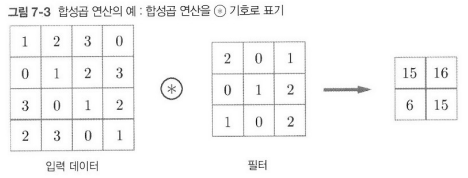   
- 그림과 같이 합성곱 연산은 입력 데이터에 필터를 적용함   
- 이 예에서 입력 데이터는 세로, 가로 방향의 형상을 가졌고, 필터 역시 세로, 가로 방향의 차원을 가짐   
- 데이터와 필터의 형상을 (높이(height), 너비(width))로 표기하며, 
- 이 예에서는 입력은 (4, 4), 필터는 (3, 3), 출력은 (2, 2)가 됨
- 문헌에 따라 필터를 **커널** 이라 칭하기도 함

그럼 그림의 합성곱 연산 예에서 어떤 계산이 이뤄지는지 설명   
합성곱 연산의 계산 순서를 그려보면   
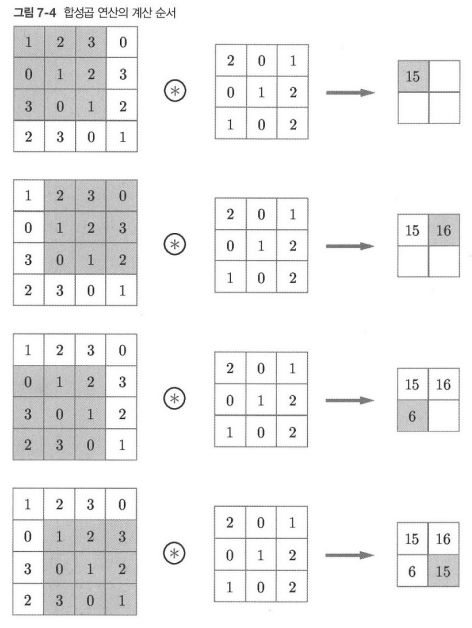   
- 합성곱 연산은 필터의 **윈도우(window)** 를 일정 간격으로 이동해가며 입력 데이터에 적용함 - 여기에서 말하는 윈도우는 그림의 회색 3 X 3 부분을 가리킴
- 이 그림에서 보듯 입력과 필터에서 대응하는 원소끼리 곱한 후 그 총합을 구함 (이 계산을 **단일 곱셈-누산(fused multiply-add, FMA)** 이라 함)
- 그리고 그 결과를 출력의 해당 장소에 저장함
- 이 과정을 모든 장소에서 수행하면 합성곱 연산의 출력이 완성됨

완전연결 신경망에는 가중치 매개변수와 편향이 존재하는데,    
CNN에서는 필터의 매개변수가 그동안의 '가중치'에 해당함   
그리고 CNN에도 편향이 존재하는데,   
위 그림은 필터를 적용하는 단계까지만 보여준 것이고, 편향까지 포함하면 아래 그림과 같은 흐름이 됨   
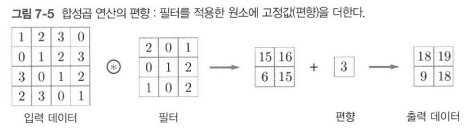   
- 그림과 같이 편향은 필터를 적용한 후의 데이터에 더해짐   
- 그리고 편향은 항상 하나(1 X 1)만 존재함   
- 그 하나의 값을 필터를 적용한 모든 원소에 더하는 것

### 패딩

합성곱 연산을 수행하기 전에 입력 데이터 주변을 특정 값(예컨대 0)을 채우기도 함 - **패딩(padding)**   
패딩은 합성곱 연산에서 자주 이용하는 기법   
- 예를 들어 (4, 4) 크기의 입력 데이터에 폭이 1인 패딩을 적용한 그림을 보면 - 폭 1짜리 패딩이라 하면 입력 데이터 사방 1픽셀을 특정 값으로 채우는 것
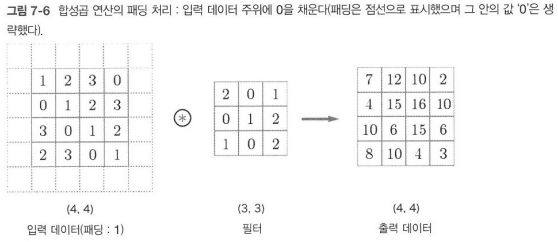   
- 그림과 같이 처음에 크기가 (4, 4)인 입력 데이터에 패딩이 추가되어 (6, 6)이 됨   
- 이 입력에 (3, 3) 크기의 필터를 걸면 (4, 4) 크기의 출력 데이터가 생성됨   
- 이 예에서는 패딩을 1로 설정했지만, 2나 3 등 원하는 정수로 설정할 수 있음   
- 만약 원래 그림에 패딩을 2로 설정하면 입력 데이터의 크기는 (8, 8)이 되고 3으로 설정하면 (10, 10)이 됨   

> 패딩은 주로 출력 크기를 조정할 목적으로 사용함   
> 예를 들어 (4, 4) 입력 데이터에 (3, 3) 필터를 적용하면 출력은 (2, 2)가 되어, 입력보다 2만큼 줄어듬   
> 이는 합성곱 연산을 몇 번이나 되풀이하는 심층 신경망에서는 문제가 될 수 있음   
> 합성곱 연산을 거칠 때마다 크기가 작아지면 어느 시점에서는 출력 크기가 1이 되어버림   
> 더 이상은 합성곱 연산을 적용할 수 없다는 뜻   
> 이러한 사태를 막기 위해 패딩을 사용함   
> 앞의 예에서는 패딩의 폭을 1로 설정하니 (4, 4) 입력에 대한 출력이 같은 크기인 (4, 4)로 유지됨   
> 한 마디로 입력 데이터의 공간적 크기를 고정한 채로 다음 계층에 전달할 수 있음

### 스트라이드

**스트라이드(stride)**: 필터를 적용하는 위치의 간격   
지금까지 본 예는 모두 스트라이드가 1이었지만,   
- 예를 들어 스트라이드를 2로 하면 필터를 적용하는 윈도우가 두 칸씩 이동함   
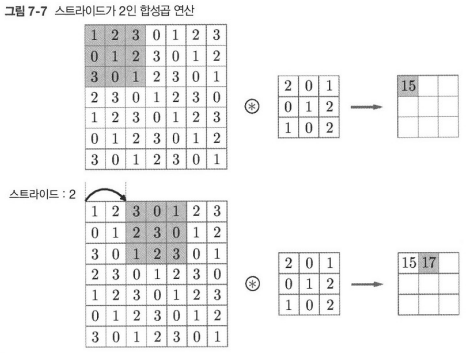   
- 그림에서는 크기가 (7, 7)인 입력 데이터에 스트라이드를 2로 설정한 필터를 적용함 - 이처럼 스트라이드는 필터를 적용하는 간격을 지정함   
- 그런데 스트라이드를 2로 하니 출력은 (3, 3)이 됨
- 이처럼 스트라이드를 키우면 출력 크기는 작아짐
- 한편, 패딩을 크게 하면 출력 크기가 커짐   

이 관계를 수식화하여 패딩, 스트라이드, 출력 크기를 계산하면   
- 입력 크기를 (H, W), 필터 크기를 (FH, FW), 출력 크기를 (OH, OW), 패딩을 P, 스트라이드를 S라 하면   
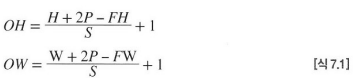   
- 이 식을 이용하여 예시를 살펴보면   
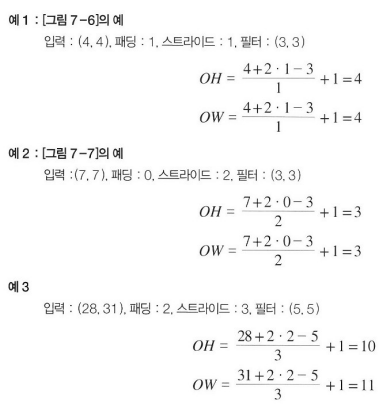   
- 위 예시에서처럼 단순히 값을 대입하기만 하면 출력 크기를 구할 수 있음   
- 단, 위에 두 식이 정수로 나누어떨어지는 값이어햐 한다는 점에 주의 - 출력 크기가 정수가 아니면 오류를 내는 등의 대응을 해줘야 함
- 딥러닝 프레임워크 중에는 값이 딱 나누어떨어지지 않을 때는 가장 가까운 정수로 반올림하는 등, 특별히 에러를 내지 않고 진행하도록 구현하는 경우도 있음

### 3차원 데이터의 합성곱 연산

지금까지 2차원 형상을 다루는 합성곱 연산을 살펴봄   
그러나 이미지만 해도 가로, 세로에 더해서 채널까지 고려한 3차원 데이터   
이번 절에서는 조금 전과 같은 순서로, 채널까지 고려한 3차원 데이터를 다루는 합성곱 연산을 살펴봄   

3차원 데이터의 합성곱 연산 예시와 계산 순서를 보면   
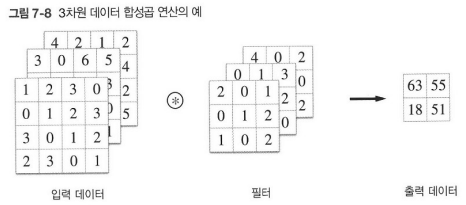   
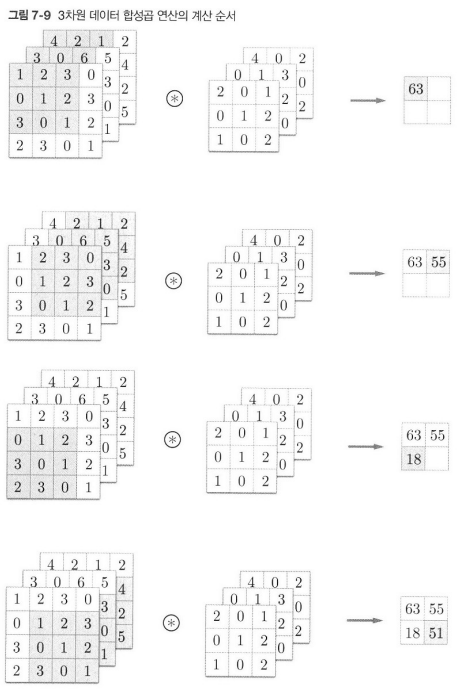   
- 2차원일 때 그림과 비교하면, 길이 방향(채널 방향)으로 특징 맵이 늘어남
- 채널 쪽으로 특징 맵이 여러 개 있다면 입력 데이터와 필터의 합성곱 연산을 채널마다 수행하고, 그 결과를 더해서 하나의 출력을 얻음
- 3차원의 합성곱 연산에서 주의할 점은 입력 데이터의 채널 수와 필터의 채널 수가 같아야 한다는 것 - 이 예에서는 모두 3개로 일치함
- 필터 자체의 크기는 원하는 값으로 설정할 수 있음 (단, 모든 채널의 필터가 같은 크기여야 함)
- 이 예에서는 필터의 크기가 (3, 3)이지만, 원한다면 (2, 2)나 (1, 1), (5, 5) 등으로 설정해도 되는 것

### 블록으로 생각하기

3차원의 합성곱 연산은 데이터와 필터를 직육면체 블록이라고 생각하면 쉬움 - 블록은 아래 그림과 같은 3차원 직육면체   
또, 3차원 데이터를 다차원 배열로 나타낼 때는 (채널(channel), 높이(height), 너비(width)) 순서로 쓸 예정   
- 예를 들어 채널 수 C, 필터 높이 FH(Filter Height), 필터 너비 FW(Filter Width)의 경우 (C, FH, FW)로 씀   
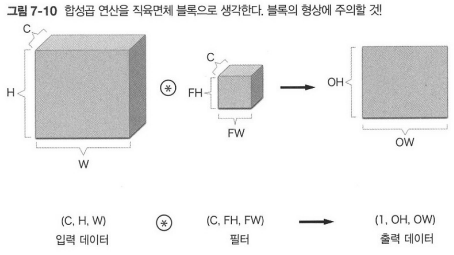   
- 이 예에서 출력 데이터는 한 장의 특징 맵 - 한 장의 특징 맵을 다른 말로 하면 채널이 1개인 특징 맵   

합성곱 연산의 출력으로 다수의 채널을 내보내려면 필터(가중치)를 다수 사용해야 함   
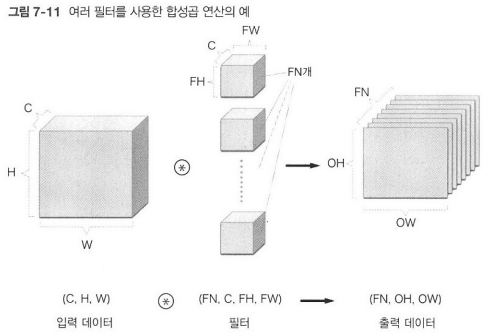   
- 이 그림과 같이 필터를 FN개 적용하면 출력 맵도 FN개가 생성됨   
- 그리고 그 FN개의 맵을 모으면 형상이 (FN, OH, OW)인 블록이 완성됨   
- 이 완성된 블록을 다음 계층으로 넘기겠다는 것이 CNN의 처리 흐름

지금까지 보듯 합성곱 연산에서는 필터의 수도 고려해야 함   
그런 이유로 필터의 가중치 데이터는 4차원 데이터이며 (출력 채널 수, 입력 채널 수, 높이, 너비) 순으로 씀   
- 예를 들어 채널 수 3, 크기 5 X 5인 필터가 20개 있ㅆ다면 (20, 3, 5, 5)로 씀   

합성곱 연산에도 (완전연결 계층과 마찬가지로) 편향이 쓰임   
위 그림에 편향을 더한 모습을 보면   
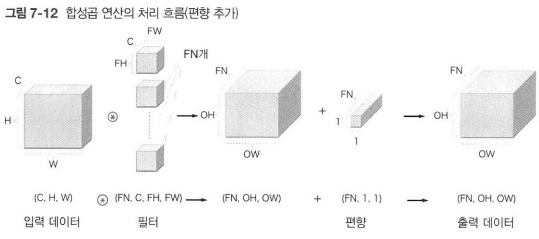   
- 그림에서 보듯 편향은 채널 하나에 값 하나씩으로 구성됨   
- 이 예에서는 편향의 형상은 (FN, 1, 1)이고, 필터의 출력 결과의 형상은 (FN, OH, OW)   
- 이 두 블록을 더하면 편향의 각 값이 필터의 출력인 (FN, OH, OW) 블록에 대응 채널의 원소 모두에 더해짐   
- 형상이 다른 블록의 덧셈은 넘파이의 브로드캐스트 기능으로 쉽게 구현할 수 있음

### 배치 처리

신경망 처리에서는 입력 데이터를 한 덩어리로 묶어 배치로 처리함   
완전연결 신경망을 구현하면서는 이 방식을 지원하여 처리 효율을 높이고, 미니배치 방식의 학습도 지원하도록 했음   

합성곱 연산도 마찬가지로 배치 처리를 지원하고자 함   
그래서 각 계층을 흐르는 데이터의 차원을 하나 늘려 4차원 데이터로 저장함   
구체적으로는 데이터를 (데이터 수, 채널 수, 높이, 너비) 순으로 저장함   
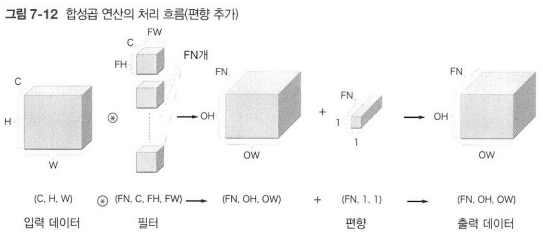   
데이터가 N개일 때 위 그림을 배치 처리한다면 데이터 형태가 아래 그림처럼 됨   
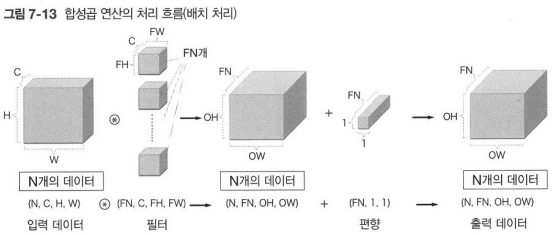   
- 배치 처리 시의 데이터 흐름을 나타낸 위 그림을 보면 각 데이터의 선두에 배치용 차원을 추가함
- 이처럼 데이터는 4차원 형상을 가진 채 각 계층을 타고 흐름   
- 여기에서 주의할 점으로는 신경망에 4차원 데이터가 하나 흐를 때마다 데이터 N개에 대한 합성곱 연산이 이루어진다는 점   
- 즉, N회 분의 처리를 한 번에 수행하는 것

## 풀링 계층

풀링은 세로, 가로 방향의 공간을 줄이는 연산   
- 예를 들어 아래 그림과 같이 2 X 2 영역을 원소 하나로 집약하여 공간 크기를 줄임   
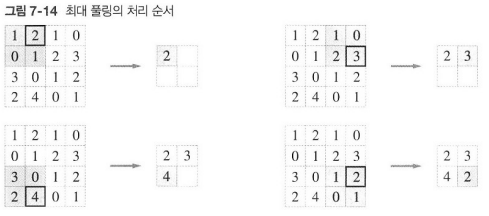   
- 위 그림은 2 X 2 **최대 풀링(max pooling, 덱스 풀링)** 을 스트라이드 2로 처리하는 순서   
- 최대 풀링은 최댓값을 구하는 연산으로, '2 X 2'는 대상 영역의 크기를 뜻함   
- 즉 2 X 2 최대 풀링은 그림과 같이 2 X 2 크기의 영역에서 가장 큰 원소 하나를 꺼냄   
- 또, 스트라이드는 이 예에서는 2로 설정했으므로 2 X 2 윈고우가 원소 2칸 간격으로 이동함   
- 참고로, 풀링의 윈도우 크기와 스트라이드는 같은 값으로 설정하는 것이 보통
    - 예를 들어 윈도우가 3 X 3이면 스트라이드는 3으로, 윈도우가 4 X 4면 스트라이드를 4로 설정함   

> 풀링은 최대 풀링 외에도 **평균 풀링(average pooling)** 등이 있음   
> 최대 풀링은 대상 영역에서 최댓값을 취하는 연산인 반면, 평균 풀링은 대상 영역의 평균을 계산함   
> 이미지 인식 분야에서는 주로 최대 풀링을 사용함   
> 그래서 이 책에서 풀링 계층이라고 하는 것은 최대 풀링을 말하는 것

### 풀링 계층의 특징

- 학습해야 할 매개변수가 없다
    - 풀링 계층은 합성곱 계층과 달리 학습해야 할 매개변수가 없음   
    - 풀링은 대상 영역에서 최댓값이나 평균을 취하는 명확한 처리이므로 특별히 학습할 것이 없음
- 채널 수가 변하지 않는다
    - 풀링 연산을 입력 데이터의 채널 수 그대로 출력 데이터로 내보냄   
    - 아래 그림처럼 채널마다 독립적으로 계산하기 때문   
    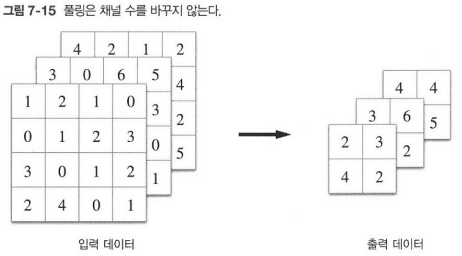   
- 입력의 변화에 영향을 적게 받는다(강건하다)
    - 입력 데이터가 조금 변해도 풀링의 결과는 잘 변하지 않음   
    - 예를 들어, 아래 그림은 입력 데이터의 차이(데이터가 오른쪽으로 1칸씨 이동)를 풀링이 흡수해 사라지게 하는 모습을 보여줌   
    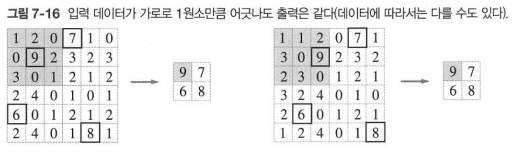

## 합성곱/풀링 계층 구현하기

이번 절에서는 합성곱 계층과 풀링 계층을 파이썬으로 구현해봄   
"5장 오차역전파법"에서 설명한 것처럼 이번 절에서 구현하는 클래스에도 forward와 backward 메서드를 추가하여 모듈로 이용할 수 있도록 함   

합성곱 계층과 풀링 계층은 복잡해 보이지만, '트릭'을 사용하면 쉽게 구현할 수 있음   

### 4차원 배열

앞에서 설명한 대로 CNN에서 계층 사이를 흐르는 데이터는 4차원   
- 예를 들어 데이터의 형상이 (10, 1, 28, 28)이라면, 이는 높이 28, 너비 28, 채널 1개인 데이터가 10개라는 이야기   

이를 파이썬으로 구현하면

In [1]:
import numpy as np

x = np.random.rand(10, 1, 28, 28)
print(x.shape)

(10, 1, 28, 28)


- 여기에서 (10개 중) 첫 번째 데이터에 접근하려면 단순히 x[0]이라고 씀
- 마찬가지로 두번째 데이터는 x[1] 위치에 있음

In [2]:
print(x[0].shape)
print(x[1].shape)

(1, 28, 28)
(1, 28, 28)


- 또, 첫 번째 데이터의 첫 채널의 공간 데이터에 접근하려면 다음과 같음

In [4]:
print(x[0, 0])
# print(x[0][0])

[[0.16195519 0.66735183 0.67039626 0.88535268 0.65727051 0.08308375
  0.07016345 0.05610465 0.31127854 0.16710698 0.92102434 0.85959045
  0.27881811 0.89341635 0.9166866  0.63802718 0.33955878 0.54445373
  0.73639887 0.91564823 0.29986393 0.57917903 0.21406573 0.51691516
  0.2687228  0.58973246 0.36959157 0.04343677]
 [0.52541389 0.76978255 0.96382044 0.13257073 0.25527226 0.75467476
  0.37574393 0.60264318 0.74742077 0.11898625 0.32255093 0.24441825
  0.20790984 0.9537966  0.35654967 0.63235857 0.23956327 0.07270067
  0.29776921 0.1565713  0.52005677 0.75030822 0.81660345 0.58838159
  0.03066164 0.05253426 0.36021692 0.62316756]
 [0.29291438 0.4009882  0.91949624 0.80956172 0.43799294 0.36799923
  0.85721408 0.64844361 0.35771806 0.61004836 0.30272785 0.58267733
  0.65066897 0.65235123 0.14346358 0.8584796  0.65315643 0.66578564
  0.51468051 0.98742682 0.7660375  0.76472691 0.29242036 0.09043922
  0.15965875 0.59699627 0.89017567 0.452871  ]
 [0.31320505 0.38689435 0.50909462 0.204495

이처럼 CNN은 4차우너 데이터를 다룸   
그래서 합성곱 연산의 구현은 복잡해질 것 같지만, 다음 절에서 설명하는 im2col 이라는 '트릭'이 문제를 단순하게 만들어줌

### im2col로 데이터 전개하기

합성곱 연산을 곧이곧대로 구현하려면 for 문을 겹겹이 써야할 것 - 귀찮고, 넘파이에 for문을 사용하면 성능이 떨어진다는 단점이 있음   
이번 절에서는 for문 대신 **im2col** 이라는 편의 함수를 사용해 간단하게 구현   

im2col은 입력 데이터를 필터링(가중치 계산)하기 좋게 전개하는(펼치는) 함수   
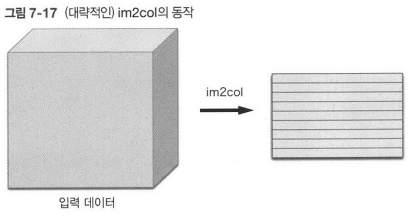   
- 그림과 같이 3차원 입력 데이터에 im2col을 적용하면 2차원 행렬로 바뀜 (정확히는 배치 안의 데이터 수까지 포함한 4차원 데이터를 2차원으로 변환함)   

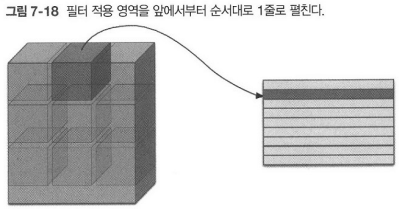   
- im2col은 필터링하기 좋게 입력 데이터를 전개함   
- 구체적으로는 위 그림과 같이 입력 데이터에서 필터를 적용하는 영역(3차원 블록)을 한 줄로 늘어놓음   
- 이 전개를 필터를 적용하는 모든 영역에서 수행하는 게 im2col

그림에서는 보기에 좋게끔 스트라이드를 크게 잡아 필터의 적용 영역이 겹치지 않도록 했지만, 실제 상황에서는 영역이 겹치는 경우가 대부분   
필터 적용 영역이 겹치게 되면 im2col로 전개한 후의 원소 수가 원래 블록의 원소 수보다 많아짐   
그래서 im2col을 사용해 구현하면 메모리를 더 많이 소비하는 단점이 있음   
하지만 컴퓨터는 큰 행렬을 묶어서 계산하는 데 탁월함   
- 예를 들어 행렬 계산 라이브러리(선형 대수 라이브러리) 등은 행렬 계산에 고도로 최적화되어 큰 행렬의 곱셈을 빠르게 계산할 수 있음   
그래서 문제를 행렬 계산으로 만들면 선형 대수 라이브러리를 활용해 효율을 높일 수 있음   

> im2col은 'image to column', 즉 '이미지에서 행렬로'라는 뜻   
> 카페(Caffe)와 체이너(Chainer) 등의 딥러닝 프레임워크는 im2col이라는 이름의 함수를 만들어 합성곱 계층을 구현할 때 이용하고 있음   

im2col로 입렫 데이터를 전개한 다음에는 합성곱 계층의 필터(가중치)를 1열로 전개하고, 두 행렬의 곱을 계산하면 됨 - 완전연결 계층의 Affine 계층에서 한 것과 거의 같음   
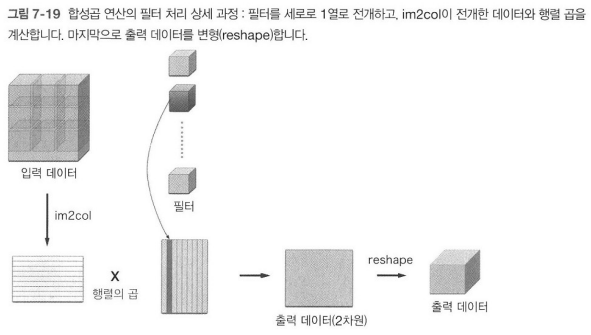   
- 그림과 같이 im2col 방식으로 출력한 결과는 2차원 행렬   
- CNN은 데이터를 4차원 배열로 저장하므로 2차원인 출력 데이터를 4차원으로 변형(reshape)함
- 여기까지가 합성곱 계층의 구현 흐름

### 합성곱 계층 구현하기

이 책에서는 im2col 함수를 미리 만들어 제공함 - 간단한 함수 10개 정도를 묶은 것

In [6]:
def im2col(input_data, filter_h, filter_w, stride=1, pad=0):

    N, C, H, W = input_data.shape
    out_h = (H + 2*pad - filter_h)//stride + 1
    out_w = (W + 2*pad - filter_w)//stride + 1

    img = np.pad(input_data, [(0,0), (0,0), (pad, pad), (pad, pad)], 'constant')
    col = np.zeros((N, C, filter_h, filter_w, out_h, out_w))

    for y in range(filter_h):
        y_max = y + stride*out_h
        for x in range(filter_w):
            x_max = x + stride*out_w
            col[:, :, y, x, :, :] = img[:, :, y:y_max:stride, x:x_max:stride]

    col = col.transpose(0, 4, 5, 1, 2, 3).reshape(N*out_h*out_w, -1)
    return col

im2col 함수의 인터페이스는 다음과 같음   
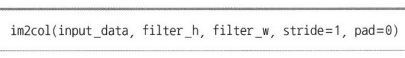   
- input_data: (**데이터 수, 채널 수, 높이, 너비**)의 4차원 배열로 이루어진 입력 데이터
- filter_h: 필터의 높이   
- filter_w: 필터의 너비   
- stride: 스트라이드   
- pad: 패딩   

이 im2col은 '필터 크기', '스트라이드', '패딩'을 고려하여 입력 데이터를 2차원 배열로 전개함   
im2col을 실제로 사용해보기

In [7]:
x1 = np.random.rand(1, 3, 7, 7)  # (데이터 수, 채널 수, 높이, 너비)
col1 = im2col(x1, 5, 5, stride=1, pad=0)
print(col1.shape)

x2 = np.random.rand(10, 3, 7, 7)  # 데이터 10개
col2 = im2col(x2, 5, 5, stride=1, pad=0)
print(col2.shape)

(9, 75)
(90, 75)


여기에서는 두 가지 예를 보여주고 있음   
- 첫 번째는 배치 크기가 1(데이터 1개), 채널은 3개, 높이 너비가 7 X 7의 데이터이고, 두 번째는 배치 크기만 10이고 나머지는 첫 번째와 같음   
- im2col 함수를 적용한 두 경우 모두 2번째 차원의 원소는 75개 - 이 값은 필터의 원소 수와 같음 (채널 3개, 5 X 5 데이터)   
- 또한 배치 크기가 1일 때는 im2col의 결과가 크기가 (9, 75)이고, 10일 때는 그 10배인 (90, 75) 크기의 데이터가 저장됨   

이제 이 im2col을 사용하여 합성곱 계층을 구현해보기 (여기에서는 합성곱 계층을 Convolution이라는 클래스로 구현함)   

In [8]:
class Convolution:
    def __init__(self, W, b, stride=1, pad=0):
        self.W = W
        self.b = b
        self.stride = stride
        self.pad = pad
    
    def forward(self, x):
        FN, C, FH, FW = self.W.shape
        N, C, H, W = x.shape
        out_h = int(1 + (H + 2*self.pad - FH) / self.stride)
        out_w = int(1 + (W + 2*self.pad - FW) / self.stride)

        col = im2col(x, FH, FW, self.stride, self.pad)
        col_W = self.W.reshape(FN, -1).T  # 필터 전개
        out = np.dot(col, col_W) + self.b

        out = out.reshape(N, out_h, out_w, -1).transpose(0, 3, 1, 2)

        return out

- 합성곱 계층은 필터(가중치), 편향, 스트라이드, 패딩을 인수로 받아 초기화함   
- 필터는 (FN, C, FH, FW)의 4차원 형상
    - 여기서 FNㅇ느 필터 개수, C는 채널, FH는 필터 높이, FW는 필터 너비
- 위 코드에서 중간에 3줄이 중요한 부분
    - 이 부분에서 입력 데이터를 im2col로 전개하고 필터도 reshape를 사용해 2차원 배열로 전개함   
    - 이렇게 전개한 두 행렬의 곱을 구함
- 필터를 전개하는 부분은 각 필터 블록을 1줄로 펼쳐 세움

- 다음으로 forward 구현의 마지막에서는 출력 데이터를 적절한 형상으로 바꿔줌   
- 이때 넘파이의 transpose 함수를 사용하는데, 이는 다차원 배열의 축 순서를 바꿔주는 함수   
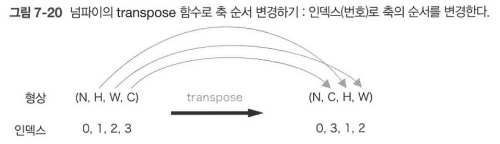   
- 그림과 같이 인덱스(0부터 시작)를 지정하여 축의 순서를 변경함   

여기까지가 합성곱 계층의 forward 구현   
im2col로 전개한 덕분에 완전연결 계층의 Affine 계층과 거의 똑같이 구현할 수 있었음   

다음은 합성곱 계층의 역전파를 구현할 차레지만,   
Affine 계층의 구현과 공통점이 많아 따로 설명하지 않음   
주의할 게 하나 있는데, 합성곱 계층의 역전파에서는 im2col을 역으로 처리해야 함   
이는 이 책이 제공하는 col2im 함수를 사용하면 됨   
col2im을 사용한다는 점을 제외하면 합성곱 계층의 역전파는 Affine 계층과 똑같음

In [9]:
def col2im(col, input_shape, filter_h, filter_w, stride=1, pad=0):
    """(im2col과 반대) 2차원 배열을 입력받아 다수의 이미지 묶음으로 변환한다.
    
    Parameters
    ----------
    col : 2차원 배열(입력 데이터)
    input_shape : 원래 이미지 데이터의 형상（예：(10, 1, 28, 28)）
    filter_h : 필터의 높이
    filter_w : 필터의 너비
    stride : 스트라이드
    pad : 패딩
    
    Returns
    -------
    img : 변환된 이미지들
    """
    N, C, H, W = input_shape
    out_h = (H + 2*pad - filter_h)//stride + 1
    out_w = (W + 2*pad - filter_w)//stride + 1
    col = col.reshape(N, out_h, out_w, C, filter_h, filter_w).transpose(0, 3, 4, 5, 1, 2)

    img = np.zeros((N, C, H + 2*pad + stride - 1, W + 2*pad + stride - 1))
    for y in range(filter_h):
        y_max = y + stride*out_h
        for x in range(filter_w):
            x_max = x + stride*out_w
            img[:, :, y:y_max:stride, x:x_max:stride] += col[:, :, y, x, :, :]

    return img[:, :, pad:H + pad, pad:W + pad]

In [10]:
class Convolution:
    def __init__(self, W, b, stride=1, pad=0):
        self.W = W
        self.b = b
        self.stride = stride
        self.pad = pad
        
        # 중간 데이터（backward 시 사용）
        self.x = None   
        self.col = None
        self.col_W = None
        
        # 가중치와 편향 매개변수의 기울기
        self.dW = None
        self.db = None

    def forward(self, x):
        FN, C, FH, FW = self.W.shape
        N, C, H, W = x.shape
        out_h = 1 + int((H + 2*self.pad - FH) / self.stride)
        out_w = 1 + int((W + 2*self.pad - FW) / self.stride)

        col = im2col(x, FH, FW, self.stride, self.pad)
        col_W = self.W.reshape(FN, -1).T

        out = np.dot(col, col_W) + self.b
        out = out.reshape(N, out_h, out_w, -1).transpose(0, 3, 1, 2)

        self.x = x
        self.col = col
        self.col_W = col_W

        return out

    def backward(self, dout):
        FN, C, FH, FW = self.W.shape
        dout = dout.transpose(0,2,3,1).reshape(-1, FN)

        self.db = np.sum(dout, axis=0)
        self.dW = np.dot(self.col.T, dout)
        self.dW = self.dW.transpose(1, 0).reshape(FN, C, FH, FW)

        dcol = np.dot(dout, self.col_W.T)
        dx = col2im(dcol, self.x.shape, FH, FW, self.stride, self.pad)

        return dx

### 풀링 계층 구현하기

풀링 계층 구현도 합성곱 계층과 마찬가지로 im2col을 사용해 입력 데이터를 전개함   
단, 풀링의 경우엔 채널 쪽이 독립적이라는 점이 합성곱 계층 때와 다름   
구체적으로는 아래 그림과 같이 풀링 적용 영역을 채널마다 독립적으로 전개함   
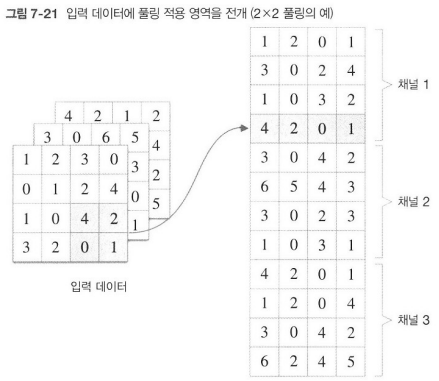   
일단 이렇게 전개한 후, 전개한 행렬에서 행별 최댓값을 구하고 적절한 형상으로 성형하기만 하면 됨   
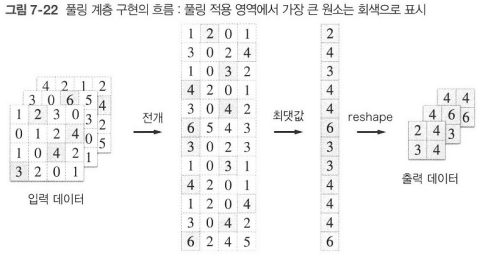   
여기까지가 forward 처리 흐름   
이를 파이썬으로 구현하면

In [11]:
class Pooling:
    def __init__(self, pool_h, pool_w, stride=1, pad=0):
        self.pool_h = pool_h
        self.pool_w = pool_w
        self.stride = stride
        self.pad = pad
    
    def forward(self, x):
        N, C, H, W = x.shape
        out_h = int(1 + (H - self.pool_h) / self.stride)
        out_w = int(1 + (W - self.pool_w) / self.stride)

        # 전개 (1)
        col = im2col(x, self.pool_h, self.pool_w, self.stride, self.pad)
        col = col.reshape(-1, self.pool_h*self.pool_w)

        # 최댓값 (2)
        out = np.max(col, axis=1)

        # 성형 (3)
        out = out.reshape(N, out_h, out_w, C).transpose(0, 3, 1, 2)

        return out

- 풀링 계층 구현은 위에 그림과 같이 다음의 세 단계로 진행함
    1. 입력 데이터를 전개한다.
    2. 행별 최댓값을 구한다.
    3. 적절한 모양으로 성형한다.

각 단계는 한두줄 정도로 간단히 구현됨   

> 최댓값 계산에는 넘파이의 np.max 메서드를 사용할 수 있음   
> np.max는 인수로 축(axis)을 지정할 수 있는데, 이 인수로 지정한 축마다 최댓값을 구할 수 있음   
> 가령 np.max(x, axis=1)과 같이 쓰면 입력 x의 1번째 차원의 축마다 최댓값을 구함   

여기까지가 풀링 계층의 forward 처리   
이 절에서 선택한 전략을 따라 입력 데이터를 풀링하기 쉬운 형태로 전개해버리면 그 후의 구현은 간단함   

풀링 계층의 backward 처리는 관련 사항을 이미 설명했으니 여기에서는 생략함   
ReLU 계층을 구현할 때 사용한 max의 역전파를 참고   

In [12]:
class Pooling:
    def __init__(self, pool_h, pool_w, stride=1, pad=0):
        self.pool_h = pool_h
        self.pool_w = pool_w
        self.stride = stride
        self.pad = pad
        
        self.x = None
        self.arg_max = None

    def forward(self, x):
        N, C, H, W = x.shape
        out_h = int(1 + (H - self.pool_h) / self.stride)
        out_w = int(1 + (W - self.pool_w) / self.stride)

        col = im2col(x, self.pool_h, self.pool_w, self.stride, self.pad)
        col = col.reshape(-1, self.pool_h*self.pool_w)

        arg_max = np.argmax(col, axis=1)
        out = np.max(col, axis=1)
        out = out.reshape(N, out_h, out_w, C).transpose(0, 3, 1, 2)

        self.x = x
        self.arg_max = arg_max

        return out

    def backward(self, dout):
        dout = dout.transpose(0, 2, 3, 1)
        
        pool_size = self.pool_h * self.pool_w
        dmax = np.zeros((dout.size, pool_size))
        dmax[np.arange(self.arg_max.size), self.arg_max.flatten()] = dout.flatten()
        dmax = dmax.reshape(dout.shape + (pool_size,)) 
        
        dcol = dmax.reshape(dmax.shape[0] * dmax.shape[1] * dmax.shape[2], -1)
        dx = col2im(dcol, self.x.shape, self.pool_h, self.pool_w, self.stride, self.pad)
        
        return dx

## CNN 구현하기

합성곱 계층과 풀링 계층을 구현했으니, 이 계층들을 조합하여 손글씨 숫자를 인식하는 CNN을 조립해보기   
여기에서 구현하는 CNN은   
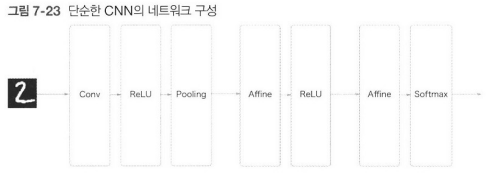
- 위 그림의 CNN 네트워크는 "Convolution-ReLU-Pooling-Affine-ReLU-Affine-Softmax" 순으로 흐름
- 이를 SimpleConvNet이라는 이름의 클래스로 구현

우선 SimpleConvNet의 초기화(\_\_init__)를 살펴보면   
초기화 때는 다음 인수들을 받음   
- input_dim: 입력 데이터(**채널 수, 높이, 너비**)의 차원
- conv_param: 합성곱 계층의 하이퍼파라미터(딕셔너리), 딕셔너리의 키는 다음과 같음
    - filter_num: 필터 수
    - filter_size: 필터 크기
    - stride: 스트라이드
    - pad: 패딩
    - hidden_size: 은닉층(완전연결)의 뉴런 수
    - output_size: 출력층(완전연결)의 뉴런 수
    - weight_init_std: 초기화 때의 거중치 표준편차

여기에서 합성곱 계층의 하이퍼파라미터는 딕셔너리 형태로 주어짐 (conv_param)   
- 이것은 필요한 하이퍼파라미터의 값이 예를 들어 {'filter_num':30, 'filter_size':5, 'pad':0, 'stride':1}처럼 저장된다는 뜻   

SimpleConvNet의 초기화는 코드가 좀 길어지므로 세 부분으로 나눠 설명함   

In [23]:
import sys, os
sys.path.append(os.pardir)

import pickle
import numpy as np
from collections import OrderedDict
from codes.layers import *
from codes.gradient import numerical_gradient

class SimpleConvNet:
    def __init__(self, input_dim=(1, 28, 28), conv_param={'filter_num':30, 'filter_size':5, 'pad':0, 'stride':1}, 
                hidden_size=100, output_size=10, weight_init_std=0.01):
        
        filter_num = conv_param['filter_num']
        filter_size = conv_param['filter_size']
        filter_pad = conv_param['pad']
        filter_stride = conv_param['stride']
        input_size = input_dim[1]
        conv_output_size = (input_size - filter_size + 2*filter_pad) / filter_stride + 1
        pool_output_size = int(filter_num * (conv_output_size/2) * (conv_output_size/2))

        # 가중치 초기화
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(filter_num, input_dim[0], filter_size, filter_size)
        self.params['b1'] = np.zeros(filter_num)
        self.params['W2'] = weight_init_std * np.random.randn(pool_output_size, hidden_size)
        self.params['b2'] = np.zeros(hidden_size)
        self.params['W3'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b3'] = np.zeros(output_size)

        # 계층 생성
        self.layers = OrderedDict()
        self.layers['Conv1'] = Convolution(self.params['W1'], self.params['b1'], conv_param['stride'], conv_param['pad'])
        self.layers['Relu1'] = Relu()
        self.layers['Pool1'] = Pooling(pool_h=2, pool_w=2, stride=2)
        self.layers['Affine1'] = Affine(self.params['W2'], self.params['b2'])
        self.layers['Relu2'] = Relu()
        self.layers['Affine2'] = Affine(self.params['W3'], self.params['b3'])

        self.last_layer = SoftmaxWithLoss()


    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)

        return x

    def loss(self, x, t):
        """손실 함수를 구한다.

        Parameters
        ----------
        x : 입력 데이터
        t : 정답 레이블
        """
        y = self.predict(x)
        return self.last_layer.forward(y, t)

    def accuracy(self, x, t, batch_size=100):
        if t.ndim != 1 : t = np.argmax(t, axis=1)
        
        acc = 0.0
        
        for i in range(int(x.shape[0] / batch_size)):
            tx = x[i*batch_size:(i+1)*batch_size]
            tt = t[i*batch_size:(i+1)*batch_size]
            y = self.predict(tx)
            y = np.argmax(y, axis=1)
            acc += np.sum(y == tt) 
        
        return acc / x.shape[0]

    def numerical_gradient(self, x, t):
        """기울기를 구한다（수치미분）.

        Parameters
        ----------
        x : 입력 데이터
        t : 정답 레이블

        Returns
        -------
        각 층의 기울기를 담은 사전(dictionary) 변수
            grads['W1']、grads['W2']、... 각 층의 가중치
            grads['b1']、grads['b2']、... 각 층의 편향
        """
        loss_w = lambda w: self.loss(x, t)

        grads = {}
        for idx in (1, 2, 3):
            grads['W' + str(idx)] = numerical_gradient(loss_w, self.params['W' + str(idx)])
            grads['b' + str(idx)] = numerical_gradient(loss_w, self.params['b' + str(idx)])

        return grads

    def gradient(self, x, t):
        """기울기를 구한다(오차역전파법).

        Parameters
        ----------
        x : 입력 데이터
        t : 정답 레이블

        Returns
        -------
        각 층의 기울기를 담은 사전(dictionary) 변수
            grads['W1']、grads['W2']、... 각 층의 가중치
            grads['b1']、grads['b2']、... 각 층의 편향
        """
        # 순전파
        self.loss(x, t)

        # 역전파
        dout = 1
        dout = self.last_layer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        # 결과 저장
        grads = {}
        grads['W1'], grads['b1'] = self.layers['Conv1'].dW, self.layers['Conv1'].db
        grads['W2'], grads['b2'] = self.layers['Affine1'].dW, self.layers['Affine1'].db
        grads['W3'], grads['b3'] = self.layers['Affine2'].dW, self.layers['Affine2'].db

        return grads
        
    def save_params(self, file_name="params.pkl"):
        params = {}
        for key, val in self.params.items():
            params[key] = val
        with open(file_name, 'wb') as f:
            pickle.dump(params, f)

    def load_params(self, file_name="params.pkl"):
        with open(file_name, 'rb') as f:
            params = pickle.load(f)
        for key, val in params.items():
            self.params[key] = val

        for i, key in enumerate(['Conv1', 'Affine1', 'Affine2']):
            self.layers[key].W = self.params['W' + str(i+1)]
            self.layers[key].b = self.params['b' + str(i+1)]

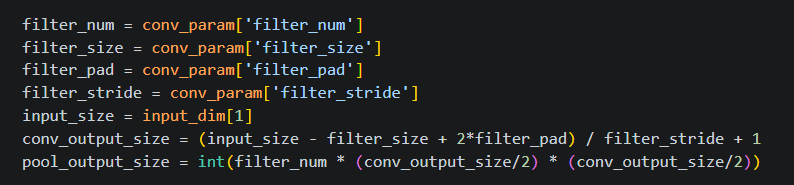   
- 여기에서는 초기화 인수로 주어진 합성곱 계층의 하이퍼파라미터를 딕셔너리에서 꺼냄 (나중에 쓰기 쉽도록)   
- 그리고 합성곱 계층의 출력 크기를 계산함   

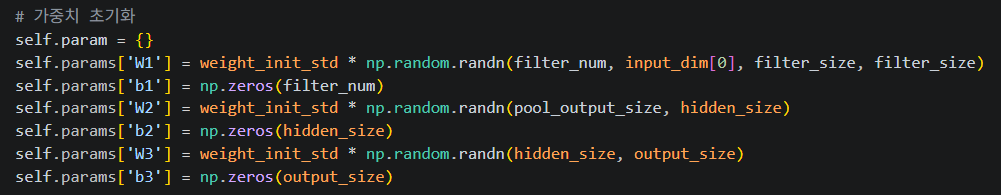   
- 가중치 매개변수를 초기화하는 부분
- 학습에 필요한 매개변수는 1번째 층의 합성곱 계층과 나머지 두 완전연결 계층의 가중치와 편향
- 이 매개변수들을 인스턴스 변수 params 딕셔너리에 저장함   
    - 1번째 층의 합성곱 계층의 가중치를 W1, 편향을 b1이라는 키로 저장
    - 마찬가지로 2번째 층의 완전연결 계층의 가중치와 편향을 W2와 b2
    - 마지막 3번째 층의 완전연결 계층의 가중치와 편향을 W3와 b3라는 키로 각각 저장함

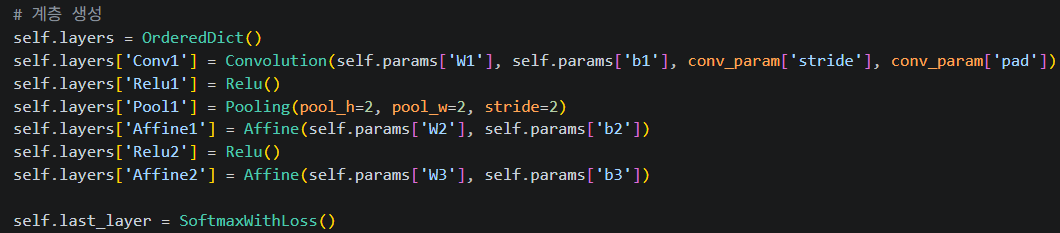   
- 마지막으로 CNN을 구성하는 계층들을 생성함   
- 순서가 있는 딕셔너리(OrderedDict)인 layers에 계층들을 차례로 추가함
- 마지막 SoftmaxWithLoss 계층만큼은 last_layer라는 별도 변수에 저장해둠

여기까지 SimpleConvNet의 초기화   
이렇게 초기화를 마친 다음에는 추론을 수행하는 predict 메서드와 손실 함수의 값을 구하는 loss 메서드를 구현   

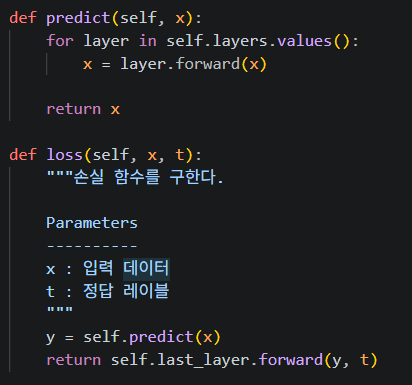   
- 이 코드에서 인수 x는 입력 데이터, t는 정답 레이블
- 추론을 수행하는 predict 메서드는 초기화 때 layers에 추가한 계층을 맨 앞에서부터 차례로 forward 메서드를 호출하며 그 결과를 다음 계층에 전달함
- 손실 함수를 구하는 loss 메서드는 predict 메서드의 결과를 인수로 마지막 층의 forward 메서드를 호출함
- 즉, 첫 계층부터 마지막 계층까지 forward를 처리함   

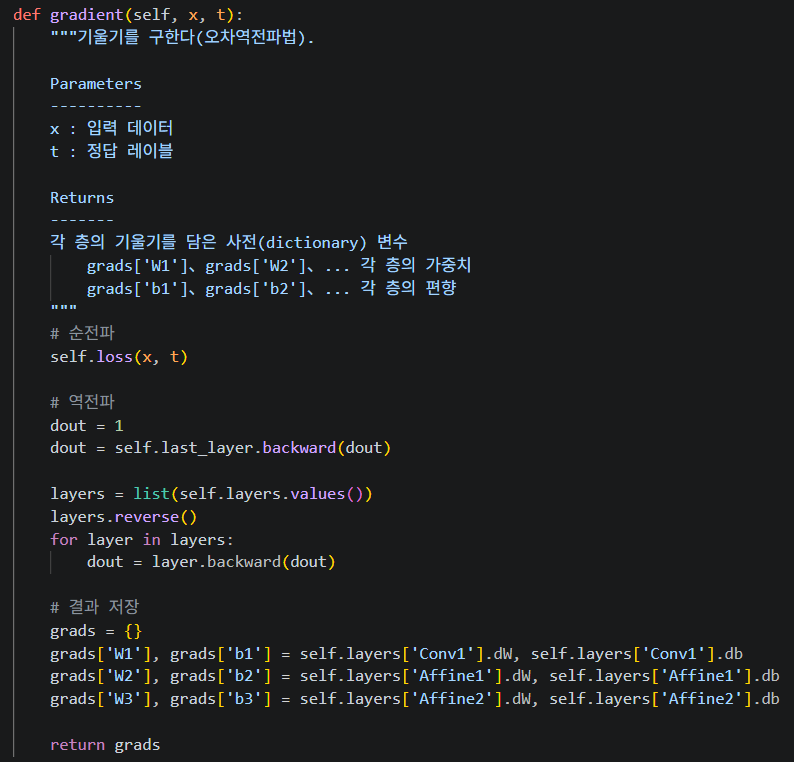   
- 이어서 오차역전파법으로 기울기를 구하는 구현   
- 매개변수의 기울기는 오차역전파법으로 구함
- 이 과정은 순전파와 역전파를 반복함
- 지금까지 각 계층의 순전파와 역전파 기능을 제대로 구현했다면, 여기에서는 단지 그것들을 적절한 순서로 호출만 해주면 됨
- 마지막으로 grads라는 딕셔너리 변수에 각 가중치 매개변수의 기울기를 저장함   

여기까지가 SimpleConvNet의 구현   

이제 이 SimpleConvNet으로 MNIST 데이터셋을 학습해볼 차례

train loss:2.30055570540149
=== epoch:1, train acc:0.231, test acc:0.216 ===
train loss:2.2992633970809497
train loss:2.2958910119679916
train loss:2.2931695931649854
train loss:2.2849607731564943
train loss:2.2784032769286267
train loss:2.261468299968178
train loss:2.2471823619580813
train loss:2.238831567484506
train loss:2.220413381730402
train loss:2.19741633865205
train loss:2.171258815694052
train loss:2.117472062362997
train loss:2.0924599583812515
train loss:2.0589127677663353
train loss:1.9707650627830802
train loss:1.9413251758396748
train loss:1.921871249798447
train loss:1.8304303830481077
train loss:1.7625692358350498
train loss:1.6565833869683513
train loss:1.574830515509075
train loss:1.579888663139596
train loss:1.5471156505734995
train loss:1.3173229802742237
train loss:1.209956423376067
train loss:1.3002696371663294
train loss:1.0902770390017427
train loss:0.9898785938110306
train loss:1.009656830924907
train loss:0.9625130067103072
train loss:0.9165800191966724
train

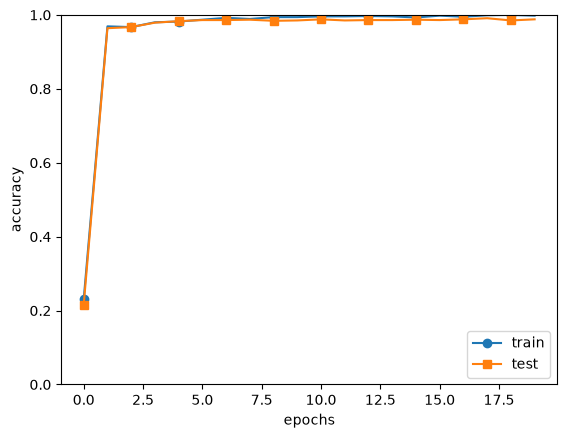

In [20]:
import sys, os
sys.path.append(os.pardir)

import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from codes.trainer import Trainer

# 데이터 읽기
(x_train, t_train), (x_test, t_test) = load_mnist(flatten=False)

# 시간이 오래 걸릴 경우 데이터를 줄인다.
#x_train, t_train = x_train[:5000], t_train[:5000]
#x_test, t_test = x_test[:1000], t_test[:1000]

max_epochs = 20

network = SimpleConvNet(input_dim=(1,28,28), 
                        conv_param = {'filter_num': 30, 'filter_size': 5, 'pad': 0, 'stride': 1},
                        hidden_size=100, output_size=10, weight_init_std=0.01)
                        
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=max_epochs, mini_batch_size=100,
                  optimizer='Adam', optimizer_param={'lr': 0.001},
                  evaluate_sample_num_per_epoch=1000)
trainer.train()

# 매개변수 보존
network.save_params("params.pkl")
print("Saved Network Parameters!")

# 그래프 그리기
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, trainer.train_acc_list, marker='o', label='train', markevery=2)
plt.plot(x, trainer.test_acc_list, marker='s', label='test', markevery=2)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

- SimpleConvNet을 MNIST 데이터셋으로 학습하면 훈련 데이터에 대한 정확도는 99.82%, 시험 데이터에 대한 정확도는 98.96%가 됨 (학습별로 정확도에는 약간의 오차가 발생)
- 시험 데이터에 대한 정확도가 무려 99%라는 것은 비교적 작은 네트워크로서는 아주 높다고 할 수 있음   
- 다음 장에서는 계층을 더 깊게 하여 시험 데이터에 대한 정확도가 99%가 넘는 네트워크도 구현해볼 예정   

지금까지 살펴본 것처럼 합성곱 계층과 풀링 계층은 이미지 인식에 필수적인 모듈   
이미지라는 공간적인 형상에 담긴 특징을 CNN이 잘 파악하여 손글씨 숫자 인식에서 높은 정확도를 달성할 수 있었음

## CNN 시각화하기

CNN을 구성하는 합성곱 계층은 입력으로 받은 이미지 데이터에서 '무엇을 보고 있는' 것인지?   
이번 절에서는 합성곱 계층을 시각화해서 CNN이 보고 있는 것이 무언인지 알아봄   

### 1번째 층의 가중치 시각화하기

앞에서 MNIST 데이터셋으로 간단한 CNN 학습을 해보았는데, 그때 1번째 층의 합성곱 계층의 가중치는 그 형상이 (30, 1, 5, 5)였음 (필터 30개, 채널 1개, 5 X 5 크기)   
필터의 크기가 5 X 5이고 채널이 1개라는 것은 이 필터를 1채널의 회색조 이미지로 시각화할 수 있다는 뜻   

그럼 합성곱 계층(1층째) 필터를 이미지로 나타내보면   
여기에서는 학습 전과 후의 가중치를 비교해볼 텐데, 그 결과는 아래 그림처럼 됨  
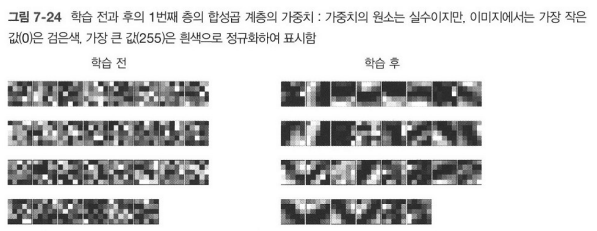   
- 위 그림과 같이 학습 전 필터는 무작위로 초기화되고 있어 흑백의 정도에 규칙성이 없음
- 한편, 학습을 마친 필터는 규칙성이 있는 이미지가 됨   
- 흰색에서 검은색으로 점차 변화하는 필터와 덩어리(블롭(blob))가 진 필터 등, 규칙을 띄는 필터로 바뀌었음   

그림의 오른쪽같이 규칙성 있는 필터는 '무엇을 보고 있는'걸까?   
- 그것은 에지(색상이 바뀐 경계선)와 블롭(국소적으로 덩어리진 영역) 등을 보고 있음   
- 가령 왼쪽 절반이 흰색이고 오른쪽 절반이 검은색인 필터는 아래 그림과 같이 세로 방향의 에지에 반응하는 필터   
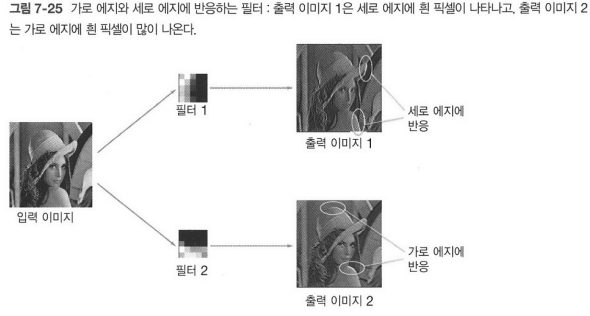   
- 위 그림은 학습된 필터 2개를 선택하여 입력 이미지에 합성곱 처리를 한 결과로, '필터 1'은 세로 에지에 반응하며 '필터 2'는 가로 에지에 반응하는 것을 알 수 있음   

이처럼 합성곱 계층의 필터는 에지나 블롭 등의 원시적인 정보를 추출할 수 있음   
이런 원시적인 정보가 뒷단 계층에 전달된다는 것이 앞에서 구현한 CNN에서 일어나는 일

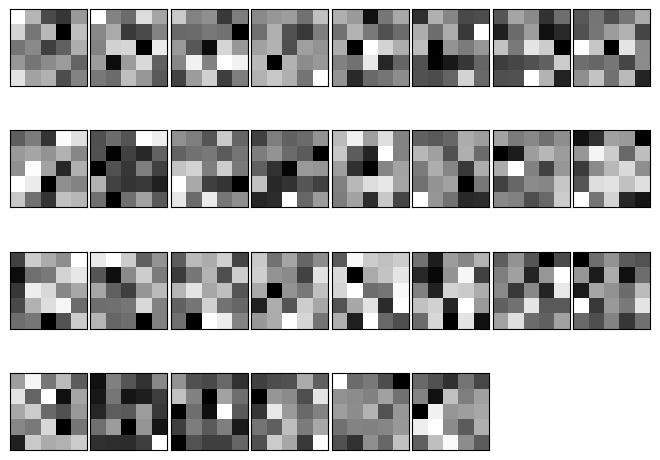

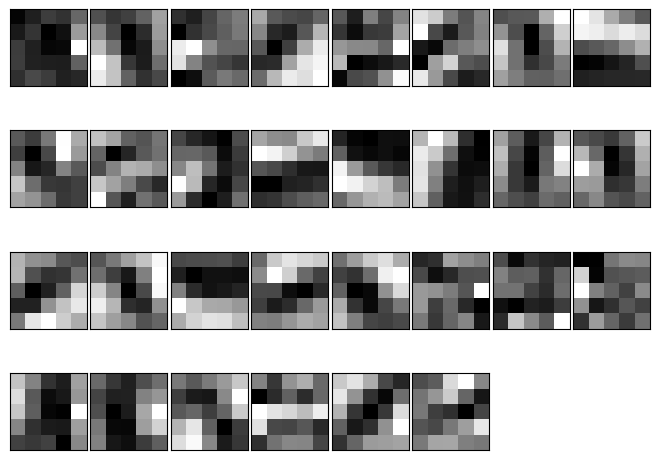

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def filter_show(filters, nx=8, margin=3, scale=10):
    """
    c.f. https://gist.github.com/aidiary/07d530d5e08011832b12#file-draw_weight-py
    """
    FN, C, FH, FW = filters.shape
    ny = int(np.ceil(FN / nx))

    fig = plt.figure()
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

    for i in range(FN):
        ax = fig.add_subplot(ny, nx, i+1, xticks=[], yticks=[])
        ax.imshow(filters[i, 0], cmap=plt.cm.gray_r, interpolation='nearest')
    plt.show()


network = SimpleConvNet()
# 무작위(랜덤) 초기화 후의 가중치
filter_show(network.params['W1'])

# 학습된 가중치
network.load_params("params.pkl")
filter_show(network.params['W1'])

### 층 깊이에 따른 추출 정보 변화

앞 절의 결과는 1번째 층의 합성곱 계층을 대상으로 한 것이었음   
1번째 층의 합성곱 계층에서는 에지나 블롭 등의 저수준 정보가 추출된다 치고, 그럼 겹겹이 쌓인 CNN의 각 계층에서는 어떤 정보가 추출될까?   
딥러닝 시각화에 관한 연구에 따르면, 계층이 깊어질수록 추출되는 정보(정확히는 강하게 반응하는 뉴런)는 더 추상화된다는 것을 알 수 있음   

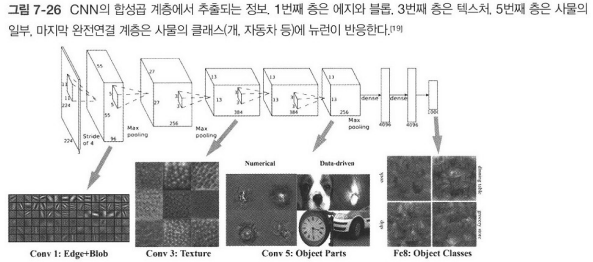   
- 위 그림은 일반 사물 인식(자동차나 개 등)을 수행한 8층의 CNN   
- 이 네트워크 구조는 AlexNet이라 하는데(다음 절에서 설명함), 합성곱 계층과 풀링 계층을 여러 겹 쌓고, 마지막으로 완전연결 계층을 거쳐 결과를 출력하는 구조
- 그림에서 블록으로 나타낸 것은 중간 데이터이며, 그 중간 데이터에 합성곱 연산을 연속해서 적용함

딥러닝의 흥미로운 점은 위 그림과 같이 합성곱 계층을 여러 겹 쌓으면, 층이 깊어지면서 더 복잡하고 추상화된 정보가 추출된다는 것   
처음 층은 단순한 에지에 반응하고, 이어서 텍스처에 반응하고, 더 복잡한 사물의 일부에 반응하도록 변화함   
즉, 층이 깊어지면서 뉴런이 반응하는 대상이 단순한 모양에서 '고급' 정보로 변화해감   
다시말하면 사물의 '의미'를 이해하도록 변화하는 것

## 대표적인 CNN

지금까지 제안된 CNN 네트워크의 구성은 다양함   
이번 절에서는 그중에서도 특히 중요한 네트워크를 두 개 소개함   
- 하나는 CNN의 원조인 LeNet
- 다른 하나는 딥러닝이 주목받도록 이끈 AlexNet

### LeNet

**LeNet** 은 손글씨 숫자를 인식하는 네트워크로, 1998년에 제안되었음   
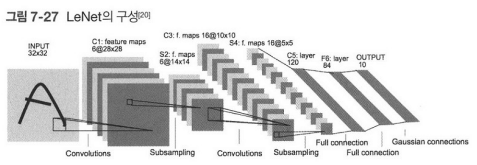   
- 그림과 같이 합성곱 계층과 풀링 계층(정확히는 단순히 '원소를 줄이기'만 하는 서브샘플링 계층)을 반복하고, 마지막으로 완전연결 계층을 거치면서 결과를 출력함
- LeNet과 '현재의 CNN'을 비교하면 몇 가지 면에서 차이가 있음
- 첫 번째 차이는 활성화 함수
    - LeNet은 시그모이드 함수를 사용하는 데 반해, 현재는 주로 ReLU를 사용함
- 또, 원래의 LeNet은 서브샘플링을 하여 중간 데이터의 크기를 줄이지만 현재는 최대 풀링이 주류   

이처럼 LeNet과 현재의 CNN은 얼마간 차이가 있지만 큰 차이는 아님   

### AlexNet

LeNet과 비교해 훨씬 최근인 2012년에 발표된 **AlexNet** 은 딥러닝 열풍을 일으키는 데 큰 역할을 했음   
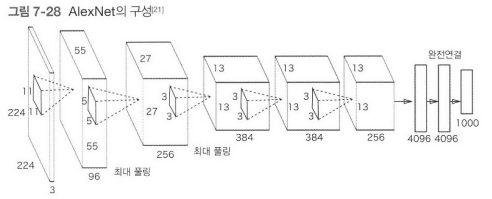   
- 그림에서 보듯 그 구성은 기본적으로 LeNet과 크게 다르지 않음   
- AlexNet은 합성곱 계층과 풀링 계층을 거듭하며 마지막으로 완전연결 계층을 거쳐 결과를 출력함
- LeNet에서 큰 구조는 바뀌지 않지만, AlexNet에서는 다음과 같은 변화를 줌
    - 활성화 함수로 ReLU를 이용한다.
    - LRN(Local Response Normalization)이라는 국소적 정규화를 실시하는 계층을 이용한다.
    - 드롭아웃을 사용한다.

여기까지 보듯 네트워크 구성 면에서는 LeNet과 AlexNet에 큰 차이는 없음   
그러나 이를 둘러싼 환경과 컴퓨터 기술이 큰 진보를 이룬 것   
대량의 데이터를 누구나 얻을 수 있게 되었고, 병렬 계산에 특화된 GPU가 보급되면서 대량의 연산을 고속으로 수행할 수 있게 됨   
빅데이터와 GPU, 이것이 딥러닝 발전의 큰 원동력   

> 딥러닝(심층 신경망)에는 대부분 수많은 매개변수가 쓰임   
> 그래서 학습하려면 엄청난 양의 계산을 해야만 함   
> 또한, 그 매개변수를 '피팅(fitting, 적합)'시키는 데이터도 대량으로 필요함   
> GPU와 빅데이터는 이런 문제에 해결책을 던졌다고 말할 수 있음

## 정리

이번 장에서는 CNN에 대해 배웠음   
CNN을 구성하는 기본 모듈인 '합성곱 계층'과 '풀링 계층'은 다소 복잡하지만, 한 번 이해하고 나면 이들을 어떻게 쓰느냐는 문제만 남음   
CNN은 이미지를 다루는 분야에서는 거의 예외 없이 쓰임

### 이번 장에서 배운 내용

- CNN은 지금까지의 완전연결 계층 네트워크에 합성곱 계층과 풀링 계층을 새로 추가한다.
- 합성곱 계층과 풀링 계층은 im2col(이미지를 행렬로 전개하는 함수)을 이용하면 간단하고 효율적으로 구현할 수 있다.
- CNN을 시각화해보면 계층이 깊어질수록 고급 정보가 추출되는 모습을 확인할 수 있다.
- 대표적인 CNN에는 LeNet과 AlexNet이 있다.
- 딥러닝의 발전에는 빅데이터와 GPU가 크게 기여했다.